## Timing Your Code, Reliably



### Benchmarks

The following code tests three difference computational tasks:
  1. A CPU-Heavy, Python-only Math Task (sum and multiply numbers in a python loop).
  2. An IO-Heavy, OS-only Task (wait until the OS says a microsecond has passed) .
  3. A CPU-Heavy, Out-of-Python Task (randomize, sum, and multiply numbers with Numpy).


We'll look at how one might want to speed up each of these, and how it impacts performance:
  1. Using Python multi-threading,
  2. Using Python multi-processing,
  3. Using multi-threading with OMP, MKL, and OPENBLAS


Finally, we'll look at difference "clocks", to understand better what they are trying to tell us, and which are more useful for interpreting performance changes:
  1. Wall Time (`time.perf_counter()`) [^1]
  2. OS Process Time (`time.process_time()`)



In [1]:
from itertools import product
import json
import subprocess, sys, os
import random

from tqdm import tqdm


### Parameters  ######################################

# Increase this for more-accurate estimates
n_repeats = 1


# Comment out any combinations you don't want to test
tasks = [
    {'task': 'cpu', 'execution': 'serial'},
    {'task': 'cpu', 'execution': 'threads'},
    {'task': 'cpu', 'execution': 'multiprocessing'},
    {'task': 'io', 'execution': 'serial'},
    {'task': 'io', 'execution': 'threads'},
    {'task': 'io', 'execution': 'multiprocessing'},
    {'task': 'numpy', 'execution': 'serial'},
    {'task': 'numpy', 'execution': 'threads'},
    {'task': 'numpy', 'execution': 'multiprocessing'},
]

# Comment out any environment variable combinations you don't want to test
envs = [
    {"OMP_NUM_THREADS": "1", "MKL_NUM_THREADS": "1", "OPENBLAS_NUM_THREADS": "1"},
    {"OMP_NUM_THREADS": "8", "MKL_NUM_THREADS": "8", "OPENBLAS_NUM_THREADS": "8"},
]

# Generates the list of runs
runs = list(product(tasks * n_repeats, envs))
random.shuffle(runs)  # try to remove any temporal relationships that might exist (probably there are more elegant ways to do this, like latin squares; just increase n_repeats for now)


### Run the Benchmarks  ##################################################

from benchmark_tool import run_benchmark_as_subprocess

results = []
for job, env in tqdm(runs):
    out =, env=os.environ | env, check=False, text=True, capture_output=True)
    if out.returncode != 0:
        print(out.stderr)
        raise RuntimeError()
    
    results.append(json.loads(out.stdout))


# Cache Results to File
with open('perf_cache.json', 'w') as f:
    json.dump(results, f)
    

  0%|          | 0/18 [00:00<?, ?it/s]


c:\Users\delgr\Projects\hhai-repo\.pixi\envs\default\python.exe: can't open file 'c:\\Users\\delgr\\Projects\\hhai-repo\\notebooks\\04_profiling\\benchmark_demo1.py': [Errno 2] No such file or directory



RuntimeError: 

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load and Preprocess Data 

In [99]:


df = pd.read_json('perf_cache.json').astype({"OMP_NUM_THREADS": int, "MKL_NUM_THREADS": int, "OPENBLAS_NUM_THREADS": int})
df['OPENBLAS_multithreaded'] = df['OPENBLAS_NUM_THREADS'].map({1: "single", 2: pd.NA, 4: "multi", 8: "multi"})
df['task_detailed'] = df['task']
df.loc[(df['task'] == 'numpy') & (df['OPENBLAS_multithreaded'] == 'multi'), 'task_detailed'] = 'numpy_multi-threaded'
df.loc[(df['task'] == 'numpy') & (df['OPENBLAS_multithreaded'] == 'single'), 'task_detailed'] = 'numpy_single-threaded'
df.dropna(inplace=True)
df.drop(columns=['OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS'], inplace=True)
def melt(df: pd.DataFrame, cols: list[str], var_name: str, value_name: str) -> pd.DataFrame:
    return df.melt(id_vars=list(df.columns.drop(cols)), value_vars=cols, var_name=var_name, value_name=value_name)

df = melt(df, ['wall', 'process', 'cpu_percent', 'io_read_count', 'io_read_bytes', 'io_read_rate', 'io_write_count', 'io_write_bytes', 'io_write_rate'], 'measurement', 'value')


df.head(10)

,task,execution,id,OPENBLAS_multithreaded,task_detailed,measurement,value
0,cpu,serial,bd7640e7,single,cpu,wall,1.086584
1,cpu,serial,bd7640e7,single,cpu,process,1.062500
2,cpu,serial,bd7640e7,single,cpu,cpu_percent,98.600000
3,cpu,serial,bd7640e7,single,cpu,io_read_count,0.000000
4,cpu,serial,bd7640e7,single,cpu,io_read_bytes,0.000000
5,cpu,serial,bd7640e7,single,cpu,io_read_rate,0.000000
6,cpu,serial,bd7640e7,single,cpu,io_write_count,0.000000
7,cpu,serial,bd7640e7,single,cpu,io_write_bytes,0.000000
8,cpu,serial,bd7640e7,single,cpu,io_write_rate,0.000000


In [91]:
df

,task,execution,id,OPENBLAS_multithreaded,task_detailed,clock,time
0,numpy,threads,9df3ff1d,single,numpy_single-threaded,wall,1.245
1,numpy,serial,ae2eea06,single,numpy_single-threaded,wall,4.833
2,numpy,threads,7f6a0538,single,numpy_single-threaded,wall,1.338
3,cpu,serial,69c527d9,single,cpu,wall,1.154
4,cpu,serial,b9cf70c2,multi,cpu,wall,1.154
...,...,...,...,...,...,...,...
175,cpu,threads,46bc001c,multi,cpu,process,1.719
176,cpu,multiprocessing,c01b55f7,single,cpu,process,2.969
177,cpu,threads,1137e28e,single,cpu,process,2.000
178,io,threads,3ca25dc8,single,io,process,0.000


### Addressing the GIL:  In-Python vs Out-of-Python (I/O)

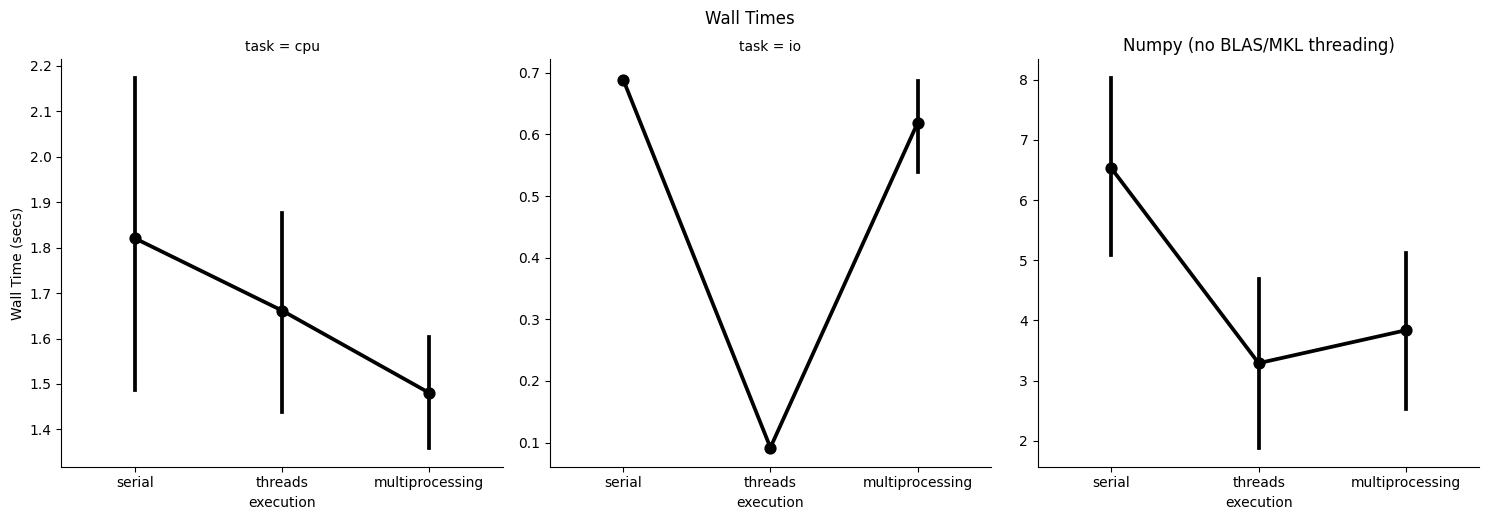

In [92]:

sns.catplot(
    data=df[(df['clock'] == 'wall') & (df['task_detailed'] != 'numpy_multi-threaded')].dropna(), 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    # hue='OPENBLAS_multithreaded', hue_order=['single', 'multi'],
    col='task', col_order=['cpu', 'io', 'numpy'], sharey=False, 
    color='black'
);
plt.suptitle('Wall Times', y=1.03)
plt.gcf().axes[0].set_ylabel('Wall Time (secs)');
plt.gcf().axes[-1].set_title('Numpy (no BLAS/MKL threading)');

### Concurrent Code and Numpy: Let the Optimizers handle it for you.

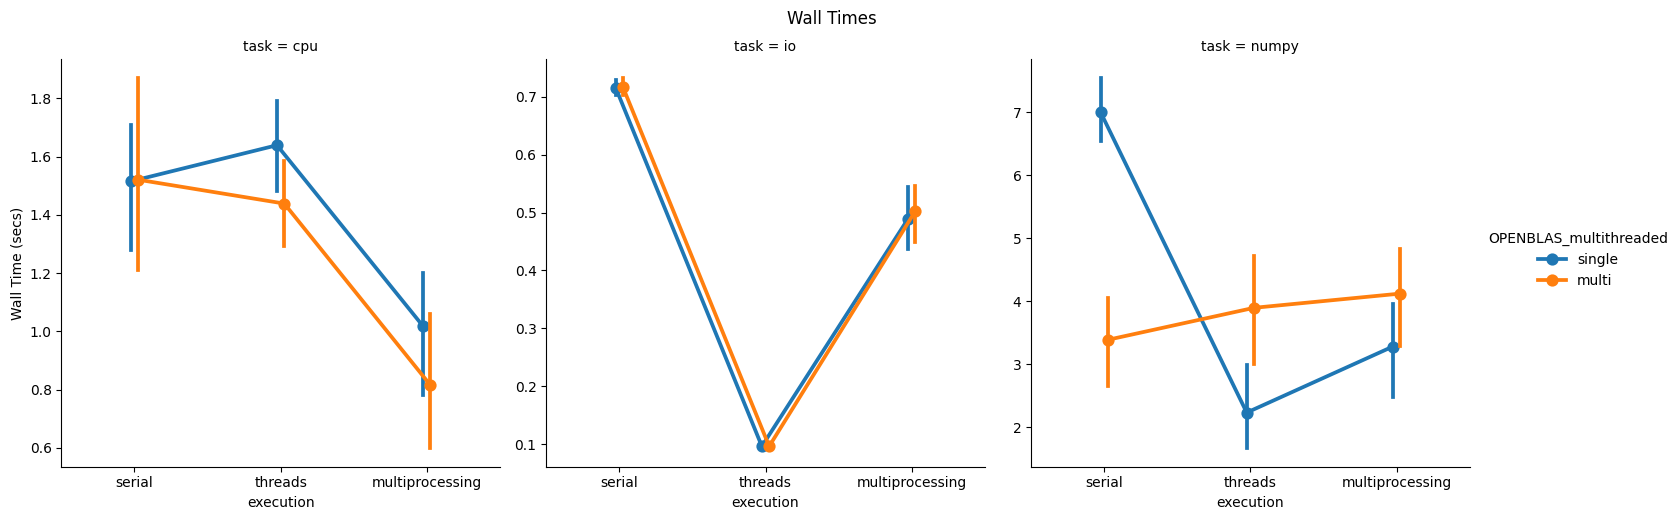

In [49]:
sns.catplot(
    data=df[(df['clock'] == 'wall')].dropna(), 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    hue='OPENBLAS_multithreaded', hue_order=['single', 'multi'],
    col='task', col_order=['cpu', 'io', 'numpy'], sharey=False, 
);
plt.suptitle('Wall Times', y=1.03)
plt.gcf().axes[0].set_ylabel('Wall Time (secs)');

### How Do I Know if my Code is IO-Bound or CPU-Bound? Comparing Wall and Process Times

In [54]:
df[(df['task_detailed'] != 'numpy_multi_threaded') & (df['execution'] == 'serial')].dropna()

,task,execution,id,OPENBLAS_multithreaded,task_detailed,clock,time
1,cpu,serial,a510b909,multi,cpu,wall,1.200
5,io,serial,e4c60c0a,single,io,wall,0.700
6,numpy,serial,b9498c20,multi,numpy_multi-threaded,wall,2.333
11,cpu,serial,838e8da8,multi,cpu,wall,1.253
13,cpu,serial,7c93dff4,multi,cpu,wall,1.260
...,...,...,...,...,...,...,...
234,io,serial,de9304a2,single,io,process,0.047
235,numpy,serial,7f141272,single,numpy_single-threaded,process,5.922
236,io,serial,8508e4cc,multi,io,process,0.031
237,cpu,serial,70bc9a42,single,cpu,process,1.031


In [61]:
df.groupby(['task_detailed', 'execution', 'clock']).time.median().unstack()

clock                                  process    wall
task_detailed         execution                       
cpu                   multiprocessing   2.7425  1.0190
                      serial            1.3985  1.4055
                      threads           1.5545  1.5790
io                    multiprocessing   0.0780  0.4995
                      serial            0.0310  0.7120
                      threads           0.0235  0.0955
numpy_multi-threaded  multiprocessing  50.6410  4.0620
                      serial           15.5310  3.2460
                      threads          44.3280  4.4470
numpy_single-threaded multiprocessing  13.3750  3.7330
                      serial            6.7340  6.8690
                      threads           7.7190  1.5290

Text(0.5, 1.03, 'I/O-bound Code: Wall Time > Process Time')

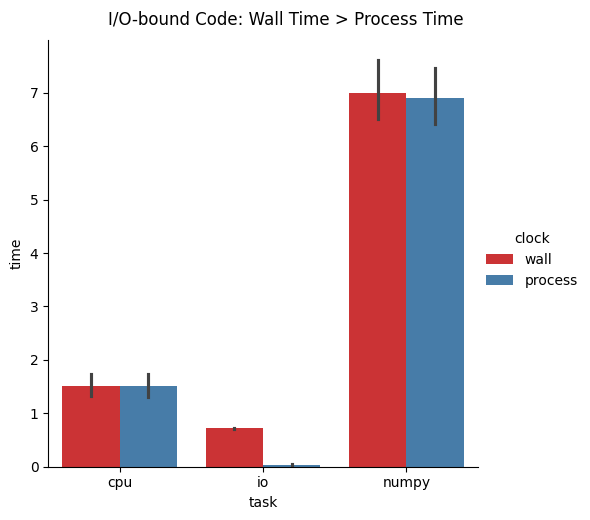

In [77]:
sns.catplot(
    data=df[(df['task_detailed'] != 'numpy_multi-threaded') & (df['execution'] == 'serial')].dropna(), 
    kind='bar', 
    x='task', y='time', dodge=True,
    hue='clock',
    palette='Set1',
);
plt.suptitle('I/O-bound Code: Wall Time > Process Time', y=1.03)

Text(0.5, 1.03, 'Parallel Processing Code: Process Time > Wall Time')

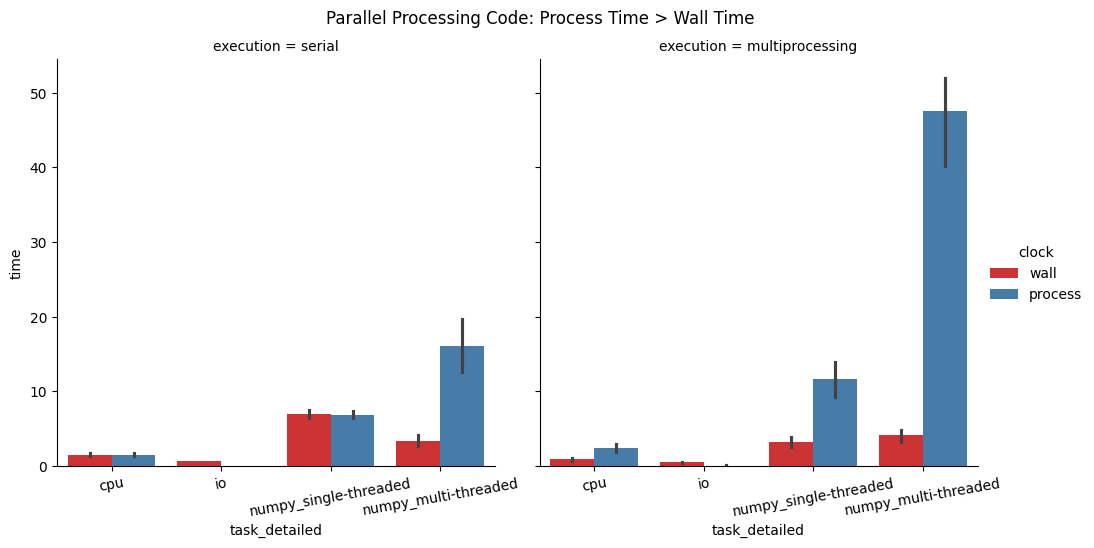

In [86]:
g = sns.catplot(
    data=df.dropna(), 
    kind='bar', 
    x='task_detailed', order=['cpu', 'io', 'numpy_single-threaded', 'numpy_multi-threaded'],
    y='time', 
    hue='clock', hue_order=['wall', 'process'],
    col='execution', col_order=['serial', 'multiprocessing'],
    palette='Set1',
);
g.set_xticklabels(rotation=10, ha="center")

plt.suptitle('Parallel Processing Code: Process Time > Wall Time', y=1.03)

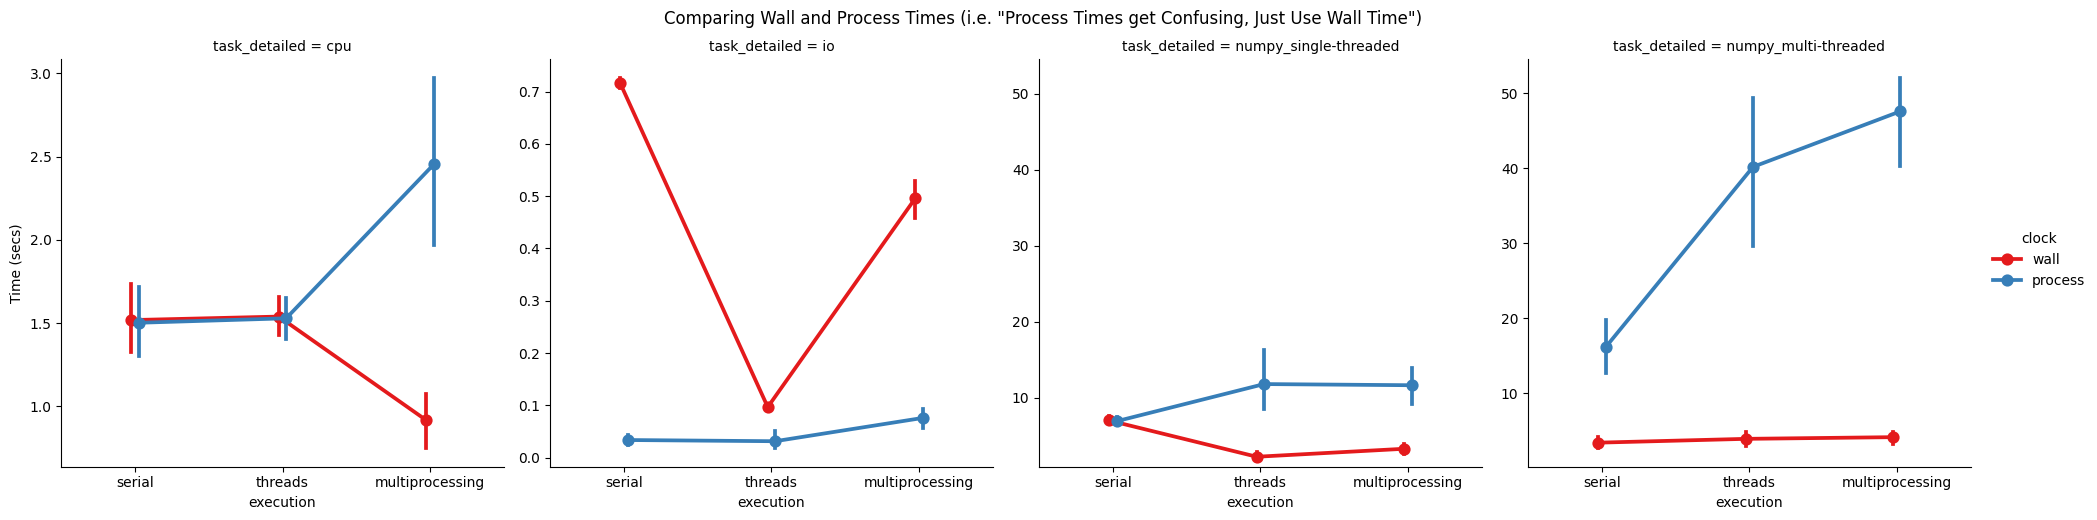

In [56]:
sns.catplot(
    data=df, 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    hue='clock',# hue_order=['single', 'multi'],
    col='task_detailed', col_order=['cpu', 'io', 'numpy_single-threaded', 'numpy_multi-threaded'], sharey=False, 
    palette='Set1',
);
plt.suptitle('Comparing Wall and Process Times (i.e. "Process Times get Confusing, Just Use Wall Time")', y=1.03)
plt.gcf().axes[0].set_ylabel('Time (secs)');
numpy_max_time = max(plt.gcf().axes[2].get_ylim()[1], plt.gcf().axes[3].get_ylim()[1])
plt.gcf().axes[2].set_ylim(None, numpy_max_time)
plt.gcf().axes[3].set_ylim(None, numpy_max_time);

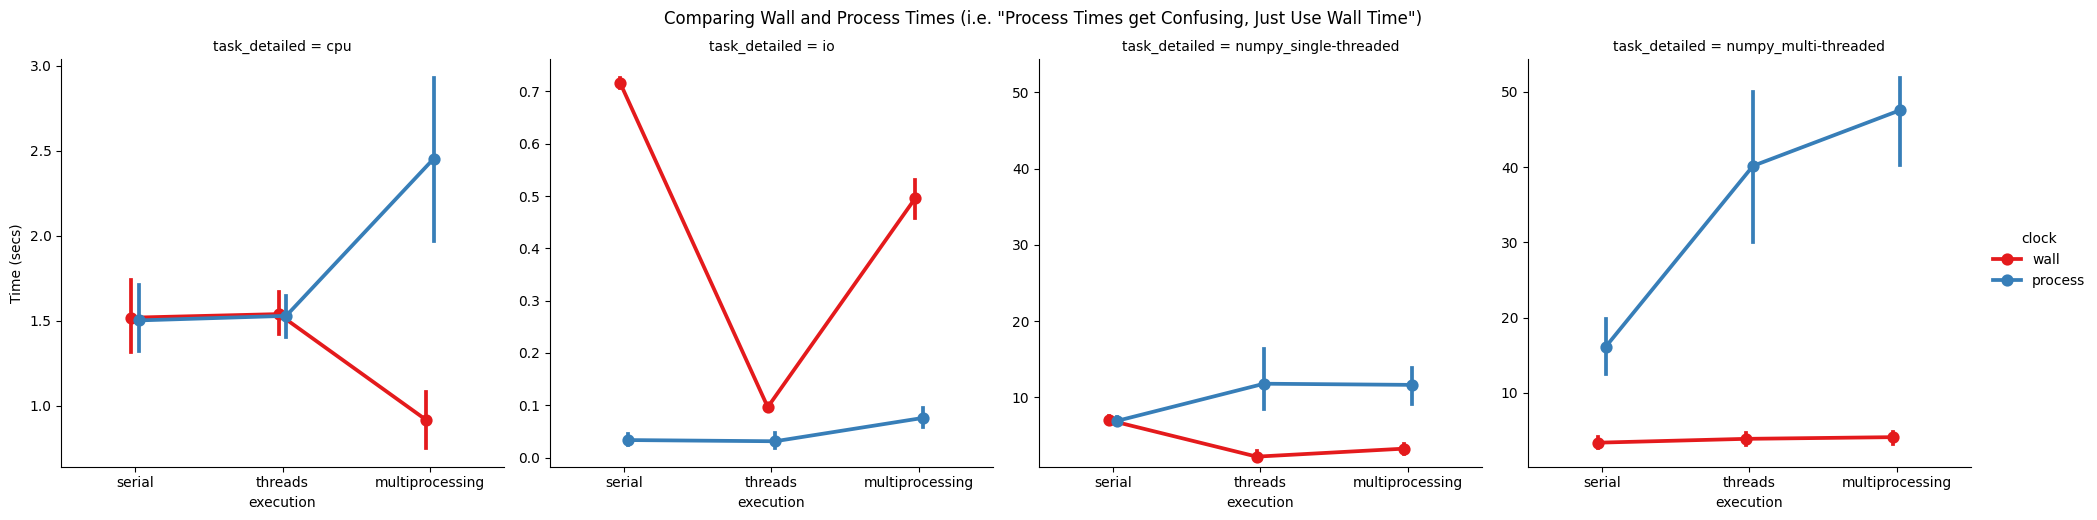

In [41]:
sns.catplot(
    data=df, 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    hue='clock',# hue_order=['single', 'multi'],
    col='task_detailed', col_order=['cpu', 'io', 'numpy_single-threaded', 'numpy_multi-threaded'], sharey=False, 
    palette='Set1',
);
plt.suptitle('Comparing Wall and Process Times (i.e. "Process Times get Confusing, Just Use Wall Time")', y=1.03)
plt.gcf().axes[0].set_ylabel('Time (secs)');
numpy_max_time = max(plt.gcf().axes[2].get_ylim()[1], plt.gcf().axes[3].get_ylim()[1])
plt.gcf().axes[2].set_ylim(None, numpy_max_time)
plt.gcf().axes[3].set_ylim(None, numpy_max_time);